In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [23]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 27.2 MB/s eta 0:00:00


In [31]:
import json
import pandas as pd
import os
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import jaccard_score
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt
import Levenshtein
import numpy as np

In [10]:
base_path = "/content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN"

spacy_json_path = f"{base_path}/DARIEN/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_spacy-lg-3.7.5.json"

spacy_ref = {
    "REF": f"{base_path}/DARIEN/REF/DARIEN_Le-voleur_REF.txt_spacy-lg-3.7.5.json",
    "TESSERACT": f"{base_path}/DARIEN/TESSERACT/DARIEN_Le-voleur_tesseract0.3.10.txt_spacy-lg-3.7.5.json",
    "KRAKEN": f"{base_path}/DARIEN/KRAKEN/DARIEN_Le-voleur_kraken4.3.13.dev25.txt_spacy-lg-3.7.5.json"
}

model_files = {
    "initial": {
        "REF": f"{base_path}/resultats_complet_initial/DARIEN_Le-voleur_REF_tok2vec_initial.json",
        "TESSERACT": f"{base_path}/resultats_complet_initial/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_initial.json",
        "KRAKEN": f"{base_path}/resultats_complet_initial/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_initial.json"
    },
    "enrichi": {
        "REF": f"{base_path}/resultats_complet_enrichi/DARIEN_Le-voleur_REF_tok2vec_enrichi.json",
        "TESSERACT": f"{base_path}/resultats_complet_enrichi/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_enrichi.json",
        "KRAKEN": f"{base_path}/resultats_complet_enrichi/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_enrichi.json"
    },
    "quaero_fusioné": {
        "REF": f"{base_path}/resultats_complet_enrichi_quaero_fusioné/DARIEN_Le-voleur_REF_tok2vec_quaero_fusioné.json",
        "TESSERACT": f"{base_path}/resultats_complet_enrichi_quaero_fusioné/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_quaero_fusioné.json",
        "KRAKEN": f"{base_path}/resultats_complet_enrichi_quaero_fusioné/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_quaero_fusioné.json"
    },
    "enrichi_80-20": {
        "REF": f"{base_path}/resultats_complet_enrichi_80-20/DARIEN_Le-voleur_REF_tok2vec_enrichi_80-20.json",
        "TESSERACT": f"{base_path}/resultats_complet_enrichi_80-20/DARIEN_Le-voleur_tesseract0.3.10_tok2vec_enrichi_80-20.json",
        "KRAKEN": f"{base_path}/resultats_complet_enrichi_80-20/DARIEN_Le-voleur_kraken4.3.13.dev25_tok2vec_enrichi_80-20.json"
    }
}

On utilise une similarité de Jaccard car plus tolérent aux petites différences ("Darien" et "Georges Darien" ne sera pas égal à 0 comme avec une similarité Levenshtein, mais une similarité partielle); capte bien les tronquages, ajouts et segmentations différentes

In [26]:
def extract_entities_from_json(json_path: str) -> List[Dict]:
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return [
        {
            "text": ent["text"],
            "start": ent["jalons"][0],
            "end": ent["jalons"][1],
            "label": ent.get("label", "")
        }
        for ent in data.values()
        if "text" in ent and "jalons" in ent and len(ent["jalons"]) == 2
    ]

def jaccard_trigram_similarity(str1: str, str2: str) -> float:
    vectorizer = CountVectorizer(analyzer='char_wb', ngram_range=(3, 3), binary=True)
    X = vectorizer.fit_transform([str1, str2]).toarray()
    return jaccard_score(X[0], X[1])

def match_entities_by_position(ents_spacy: List[Dict], ents_model: List[Dict], tolerance: int = 5) -> List[float]:
    similarities = []
    for ent_s in ents_spacy:
        best_match = None
        best_overlap = 0
        for ent_m in ents_model:
            if abs(ent_s['start'] - ent_m['start']) <= tolerance and abs(ent_s['end'] - ent_m['end']) <= tolerance:
                overlap = len(set(range(ent_s['start'], ent_s['end'])) & set(range(ent_m['start'], ent_m['end'])))
                if overlap > best_overlap:
                    best_overlap = overlap
                    best_match = ent_m
        if best_match:
            sim = jaccard_trigram_similarity(ent_s["text"], best_match["text"])
            similarities.append(sim)
    return similarities

def levenshtein_similarity(str1: str, str2: str) -> float:
    if not str1 and not str2:
        return 1.0
    distance = Levenshtein.distance(str1, str2)
    max_len = max(len(str1), len(str2))
    return 1.0 - (distance / max_len)

def match_entities_by_position_levenshtein(
    ents_spacy: List[Dict],
    ents_model: List[Dict],
    tolerance: int = 5
) -> List[float]:
    similarities = []
    for ent_s in ents_spacy:
        best_match = None
        best_overlap = 0
        for ent_m in ents_model:
            if abs(ent_s['start'] - ent_m['start']) <= tolerance and abs(ent_s['end'] - ent_m['end']) <= tolerance:
                overlap = len(set(range(ent_s['start'], ent_s['end'])) & set(range(ent_m['start'], ent_m['end'])))
                if overlap > best_overlap:
                    best_overlap = overlap
                    best_match = ent_m
        if best_match:
            sim = levenshtein_similarity(ent_s["text"], best_match["text"])
            similarities.append(sim)
    return similarities

In [20]:
global_scores = []

for modele, ocr_dict in model_files.items():
    for ocr, model_json_path in ocr_dict.items():
        try:
            ents_spacy = extract_entities_from_json(spacy_ref[ocr])
            ents_model = extract_entities_from_json(model_json_path)
            similarities = match_entities_by_position(ents_spacy, ents_model, tolerance=5)
            avg_sim = sum(similarities) / len(similarities) if similarities else 0.0
            global_scores.append({
                "modele": modele,
                "ocr": ocr,
                "nb_matches": len(similarities),
                "similarite_moyenne_trigramme": round(avg_sim, 4)
            })
        except Exception as e:
            global_scores.append({
                "modele": modele,
                "ocr": ocr,
                "nb_matches": 0,
                "similarite_moyenne_trigramme": 0.0,
                "erreur": str(e)
            })

output_csv_path = f"{base_path}/similarite_trigrammes/similarite_par_modele_ocr_jaccard.csv"
df_summary = pd.DataFrame(global_scores)
df_summary.to_csv(output_csv_path, index=False, encoding='utf-8')
print(f"Fichier enregistré : {output_csv_path}")

Fichier enregistré : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/similarite_par_modele_ocr_jaccard.csv


In [21]:
df_global = df_summary[df_summary["nb_matches"] > 0]
df_model_avg = df_global.groupby("modele").agg({
    "similarite_moyenne_trigramme": "mean",
    "nb_matches": "sum"
}).reset_index().sort_values(by="similarite_moyenne_trigramme", ascending=False)

output_avg_path = f"{base_path}/similarite_trigrammes/similarite_moyenne_par_modele_jaccard.csv"
df_model_avg.to_csv(output_avg_path, index=False, encoding='utf-8')
print(f"Fichier enregistré : {output_avg_path}")

Fichier enregistré : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/similarite_moyenne_par_modele_jaccard.csv


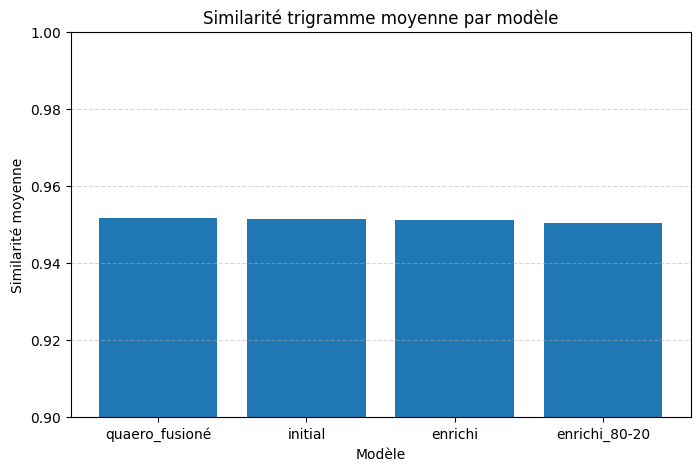

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(df_model_avg["modele"], df_model_avg["similarite_moyenne_trigramme"])
plt.title("Similarité trigramme moyenne par modèle")
plt.ylabel("Similarité moyenne")
plt.xlabel("Modèle")
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plot_path = f"{base_path}/similarite_trigrammes/barplot_similarite_moyenne_par_modele_jaccard.png"
plt.savefig(plot_path)
plt.show()

On va également faire une similarité avec Levenshtein


In [27]:
global_scores_levenshtein = []

for modele, ocr_dict in model_files.items():
    for ocr, model_json_path in ocr_dict.items():
        try:
            ents_spacy = extract_entities_from_json(spacy_ref[ocr])
            ents_model = extract_entities_from_json(model_json_path)
            similarities = match_entities_by_position_levenshtein(ents_spacy, ents_model, tolerance=5)
            avg_sim = sum(similarities) / len(similarities) if similarities else 0.0
            global_scores_levenshtein.append({
                "modele": modele,
                "ocr": ocr,
                "nb_matches": len(similarities),
                "similarite_moyenne_levenshtein": round(avg_sim, 4)
            })
        except Exception as e:
            global_scores_levenshtein.append({
                "modele": modele,
                "ocr": ocr,
                "nb_matches": 0,
                "similarite_moyenne_levenshtein": 0.0,
                "erreur": str(e)
            })

output_lev_csv = f"{base_path}/similarite_trigrammes/similarite_levenshtein_global_par_modele_ocr.csv"
df_levenshtein = pd.DataFrame(global_scores_levenshtein)
df_levenshtein.to_csv(output_lev_csv, index=False, encoding='utf-8')
print(f" Résultats Levenshtein enregistrés ici : {output_lev_csv}")

 Résultats Levenshtein enregistrés ici : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/similarite_levenshtein_global_par_modele_ocr.csv


In [28]:
df_lev_global = df_levenshtein[df_levenshtein["nb_matches"] > 0]
df_lev_model_avg = df_lev_global.groupby("modele").agg({
    "similarite_moyenne_levenshtein": "mean",
    "nb_matches": "sum"
}).reset_index().sort_values(by="similarite_moyenne_levenshtein", ascending=False)

df_lev_model_avg

output_lev_path = f"{base_path}/similarite_trigrammes/similarite_moyenne_par_modele_Levenshtein.csv"
df_lev_model_avg.to_csv(output_lev_path, index=False, encoding='utf-8')
print(f"Fichier enregistré : {output_avg_path}")

Fichier enregistré : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/similarite_moyenne_par_modele_jaccard.csv


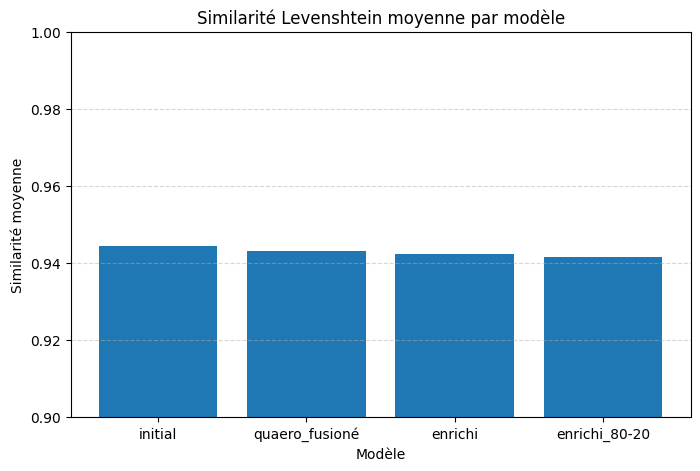

Graphique Levenshtein enregistré ici : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/barplot_similarite_levenshtein_par_modele.png


In [29]:
plt.figure(figsize=(8, 5))
plt.bar(df_lev_model_avg["modele"], df_lev_model_avg["similarite_moyenne_levenshtein"])
plt.title("Similarité Levenshtein moyenne par modèle")
plt.ylabel("Similarité moyenne")
plt.xlabel("Modèle")
plt.ylim(0.9, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plot_path_lev = f"{base_path}/similarite_trigrammes/barplot_similarite_levenshtein_par_modele.png"
plt.savefig(plot_path_lev)
plt.show()

print(f"Graphique Levenshtein enregistré ici : {plot_path_lev}")

Comparaison entre Jaccard et Levenshtein

In [30]:
df_comparaison = df_model_avg.merge(
    df_lev_model_avg,
    on="modele",
    suffixes=("_jaccard", "_levenshtein")
)
df_comparaison

,modele,similarite_moyenne_trigramme,nb_matches_jaccard,similarite_moyenne_levenshtein,nb_matches_levenshtein
0,quaero_fusioné,0.951833,4111,0.943067,4111
1,initial,0.951333,1095,0.944500,1095
2,enrichi,0.951267,4762,0.942233,4762
3,enrichi_80-20,0.950367,3884,0.941633,3884


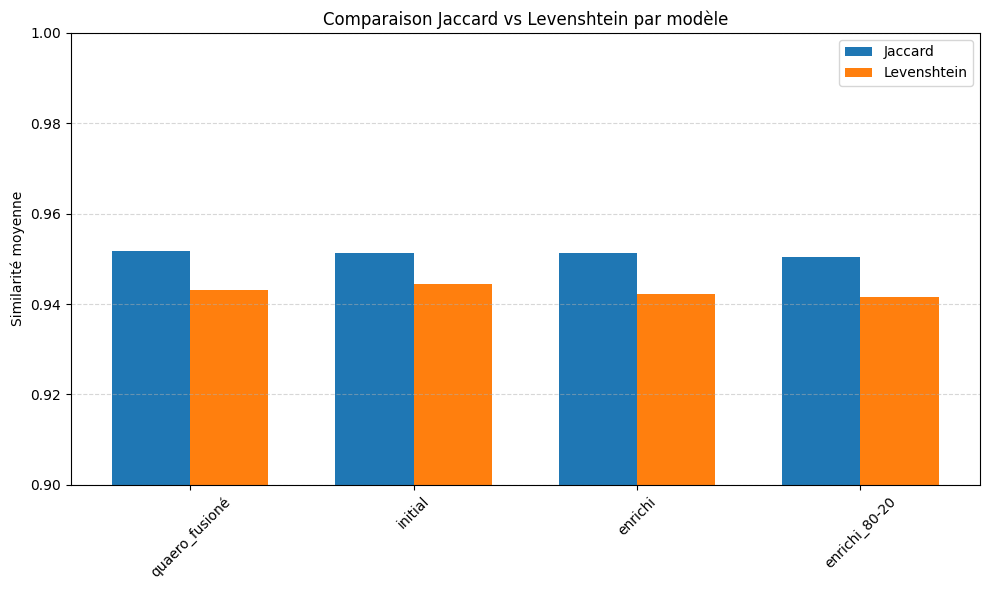

Comparaison Jaccard vs Levenshtein enregistrée ici : /content/drive/MyDrive/Colab Notebooks/Memoire_M1/Evaluation_DARIEN/similarite_trigrammes/comparaison_jaccard_vs_levenshtein.png


In [33]:
labels = df_comparaison["modele"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, df_comparaison["similarite_moyenne_trigramme"], width, label="Jaccard")
plt.bar(x + width/2, df_comparaison["similarite_moyenne_levenshtein"], width, label="Levenshtein")

plt.ylabel("Similarité moyenne")
plt.title("Comparaison Jaccard vs Levenshtein par modèle")
plt.xticks(x, labels, rotation=45)
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Enregistrement
plot_comp = f"{base_path}/similarite_trigrammes/comparaison_jaccard_vs_levenshtein.png"
plt.tight_layout()
plt.savefig(plot_comp)
plt.show()

print(f"Comparaison Jaccard vs Levenshtein enregistrée ici : {plot_comp}")